In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
def plot_rps_time_series(df, title):
    df['TIMESTAMP'] = pd.to_datetime(df['TIMESTAMP'])
    df['timestamp_sec'] = df['TIMESTAMP'].dt.floor('s')
    rps_data = df.groupby('timestamp_sec').size().reset_index(name='rps')
    start_time = rps_data['timestamp_sec'].min()
    end_time = rps_data['timestamp_sec'].max()
    complete_time_range = pd.date_range(start=start_time, end=end_time, freq='s')
    rps_complete = pd.DataFrame({'timestamp_sec': complete_time_range})
    rps_complete = rps_complete.merge(rps_data, on='timestamp_sec', how='left')
    rps_complete['rps'] = rps_complete['rps'].fillna(0)

    avg_rps = np.mean(rps_complete['rps'])
    std_rps = np.std(rps_complete['rps'])
    min_rps = np.min(rps_complete['rps'])
    max_rps = np.max(rps_complete['rps'])
    print(f"Average RPS: {avg_rps:.2f}")
    print(f"Standard Deviation: {std_rps:.2f}")
    print(f"Minimum RPS: {min_rps:.2f}")
    print(f"Maximum RPS: {max_rps:.2f}")
    avg_context_tokens = np.mean(df['ContextTokens'])
    std_context_tokens = np.std(df['ContextTokens'])
    min_context_tokens = np.min(df['ContextTokens'])
    max_context_tokens = np.max(df['ContextTokens'])
    print(f"Average Context Tokens: {avg_context_tokens:.2f}")
    print(f"Standard Deviation of Context Tokens: {std_context_tokens:.2f}")
    print(f"Minimum Context Tokens: {min_context_tokens:.2f}")
    print(f"Maximum Context Tokens: {max_context_tokens:.2f}")
    avg_generated_tokens = np.mean(df['GeneratedTokens'])
    std_generated_tokens = np.std(df['GeneratedTokens'])
    min_generated_tokens = np.min(df['GeneratedTokens'])
    max_generated_tokens = np.max(df['GeneratedTokens'])
    print(f"Average Generated Tokens: {avg_generated_tokens:.2f}")
    print(f"Standard Deviation of Generated Tokens: {std_generated_tokens:.2f}")
    print(f"Minimum Generated Tokens: {min_generated_tokens:.2f}")
    print(f"Maximum Generated Tokens: {max_generated_tokens:.2f}")

    rps_complete.to_csv('azure_conv_rps_timeseries.csv', index=False)
    print(f"\nRPS time series data exported to 'azure_rps_timeseries.csv'")
    print(f"RPS list (first 20 values): {rps_complete['rps'].head(20).tolist()}")
    # Create time series plot
    plt.figure(figsize=(10, 5))

    # Plot RPS over time
    plt.subplot(2, 1, 1)
    plt.plot(rps_complete['timestamp_sec'], rps_complete['rps'], linewidth=1, alpha=0.7)
    
    # create timestamp_sec to rps df
    timestamp_sec_to_rps = rps_complete[['timestamp_sec', 'rps']]
    timestamp_sec_to_rps.to_csv(f'{title}_timestamp_sec_to_rps.csv', index=False)
    
    plt.title(f'{title}, Azure LLM Inference Trace - Requests Per Second (RPS) Time Series', fontsize=14, fontweight='bold')
    plt.xlabel('Time')
    plt.ylabel('Requests Per Second (RPS)')
    plt.grid(True, alpha=0.3)
    plt.xticks(rotation=45)

    # Add statistics text
    stats_text = f"""Statistics:
    Total Requests: {len(df):,}
    Duration: {(end_time - start_time).total_seconds():.0f} seconds
    Average RPS: {len(df) / (end_time - start_time).total_seconds():.2f}
    Max RPS: {rps_complete['rps'].max():.0f}
    Min RPS: {rps_complete['rps'].min():.0f}"""

    plt.text(0.02, 0.98, stats_text, transform=plt.gca().transAxes, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

    # Plot histogram of RPS values
    plt.subplot(2, 1, 2)
    plt.hist(rps_complete['rps'], bins=50, alpha=0.7, edgecolor='black')
    plt.title(f'{title}, RPS Distribution', fontsize=12, fontweight='bold')
    plt.xlabel('Requests Per Second')
    plt.ylabel('Frequency (number of seconds)')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

def plot_input_output_length_distribution(df, title):
    # Create distribution plots
    input_lengths = df['ContextTokens'].values
    output_lengths = df['GeneratedTokens'].values

    fig, axes = plt.subplots(1, 2, figsize=(8, 3))
    axes[0].hist(input_lengths, bins=50, alpha=0.7, edgecolor='black')
    axes[0].set_title(f'{title}, Input Length Distribution')
    axes[0].set_xlabel('Input Length')
    axes[0].set_ylabel('Frequency')
    
    axes[1].hist(output_lengths, bins=50, alpha=0.7, edgecolor='black')
    axes[1].set_title(f'{title}, Output Length Distribution')
    axes[1].set_xlabel('Output Length')
    axes[1].set_ylabel('Frequency')

    plt.tight_layout()
    plt.show()

Average RPS: 5.53
Standard Deviation: 2.71
Minimum RPS: 0.00
Maximum RPS: 19.00
Average Context Tokens: 1154.70
Standard Deviation of Context Tokens: 1108.79
Minimum Context Tokens: 2.00
Maximum Context Tokens: 14050.00
Average Generated Tokens: 211.13
Standard Deviation of Generated Tokens: 162.87
Minimum Generated Tokens: 7.00
Maximum Generated Tokens: 1000.00

RPS time series data exported to 'azure_rps_timeseries.csv'
RPS list (first 20 values): [1.0, 0.0, 0.0, 0.0, 1.0, 2.0, 2.0, 0.0, 2.0, 3.0, 3.0, 2.0, 2.0, 3.0, 3.0, 0.0, 0.0, 0.0, 3.0, 2.0]


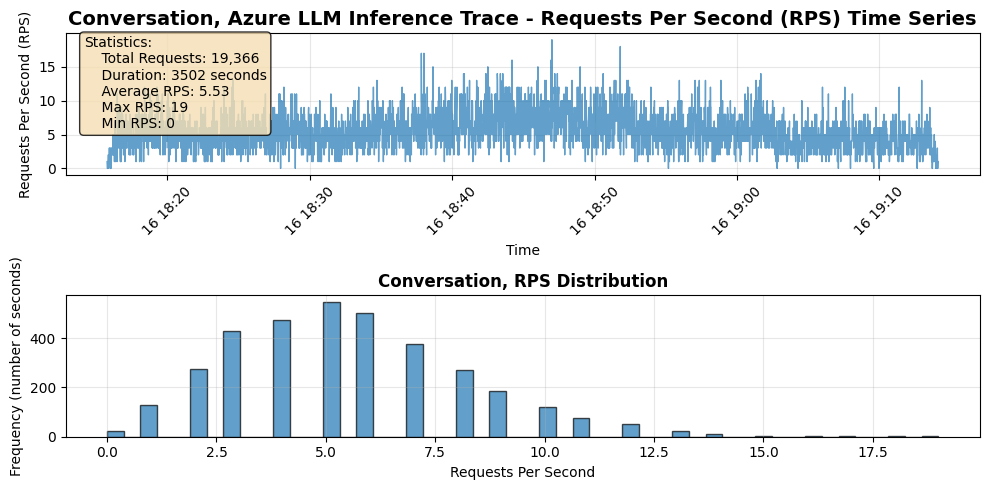

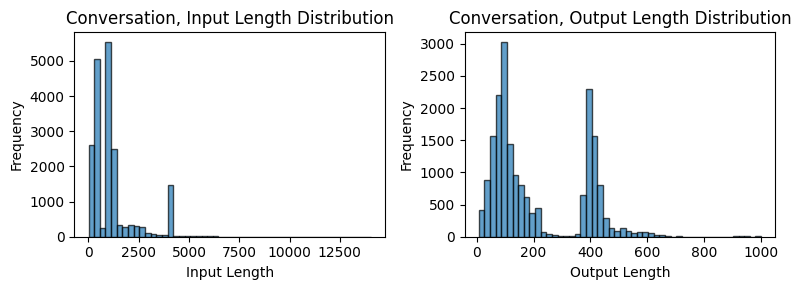

Average RPS: 2.57
Standard Deviation: 5.82
Minimum RPS: 0.00
Maximum RPS: 67.00
Average Context Tokens: 2047.85
Standard Deviation of Context Tokens: 1973.77
Minimum Context Tokens: 3.00
Maximum Context Tokens: 7437.00
Average Generated Tokens: 27.88
Standard Deviation of Generated Tokens: 59.86
Minimum Generated Tokens: 6.00
Maximum Generated Tokens: 1899.00

RPS time series data exported to 'azure_rps_timeseries.csv'
RPS list (first 20 values): [1.0, 7.0, 4.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]


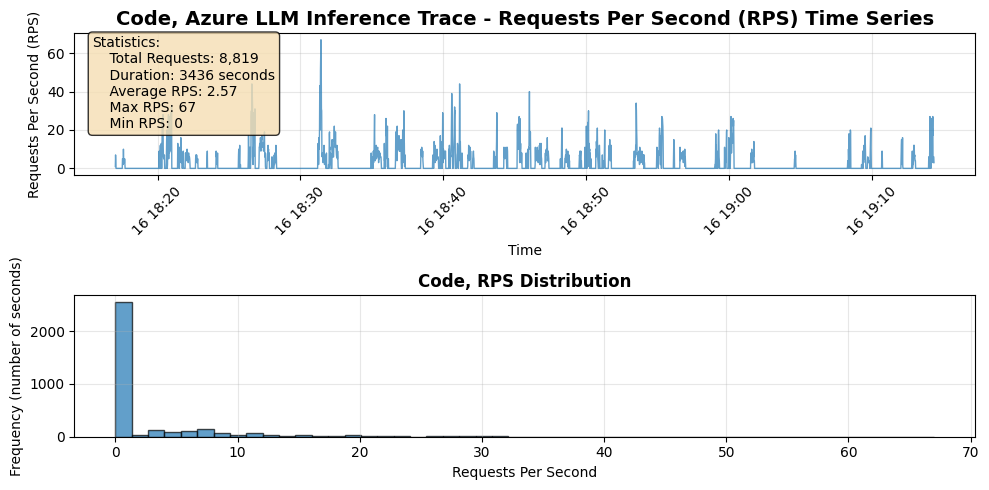

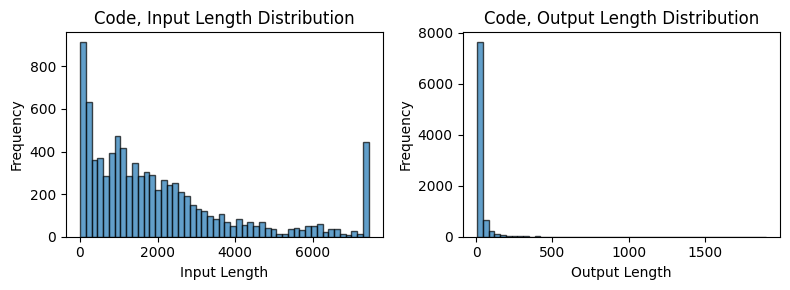

In [9]:
df_conv = pd.read_csv('AzureLLMInferenceTrace_conv.csv')
plot_rps_time_series(df_conv, "Conversation")
plot_input_output_length_distribution(df_conv, "Conversation")

df_code = pd.read_csv('AzureLLMInferenceTrace_code.csv')
plot_rps_time_series(df_code, "Code")
plot_input_output_length_distribution(df_code, "Code")

=== Comparison: Original vs Normal Distribution ===
Original Context Tokens - Mean: 1154.70, Std: 1108.79
Original Generated Tokens - Mean: 211.13, Std: 162.87

Sampled from Original - Context Mean: 1165.96, Generated Mean: 210.34
Sampled from Normal - Context Mean: 1166.81, Generated Mean: 214.38


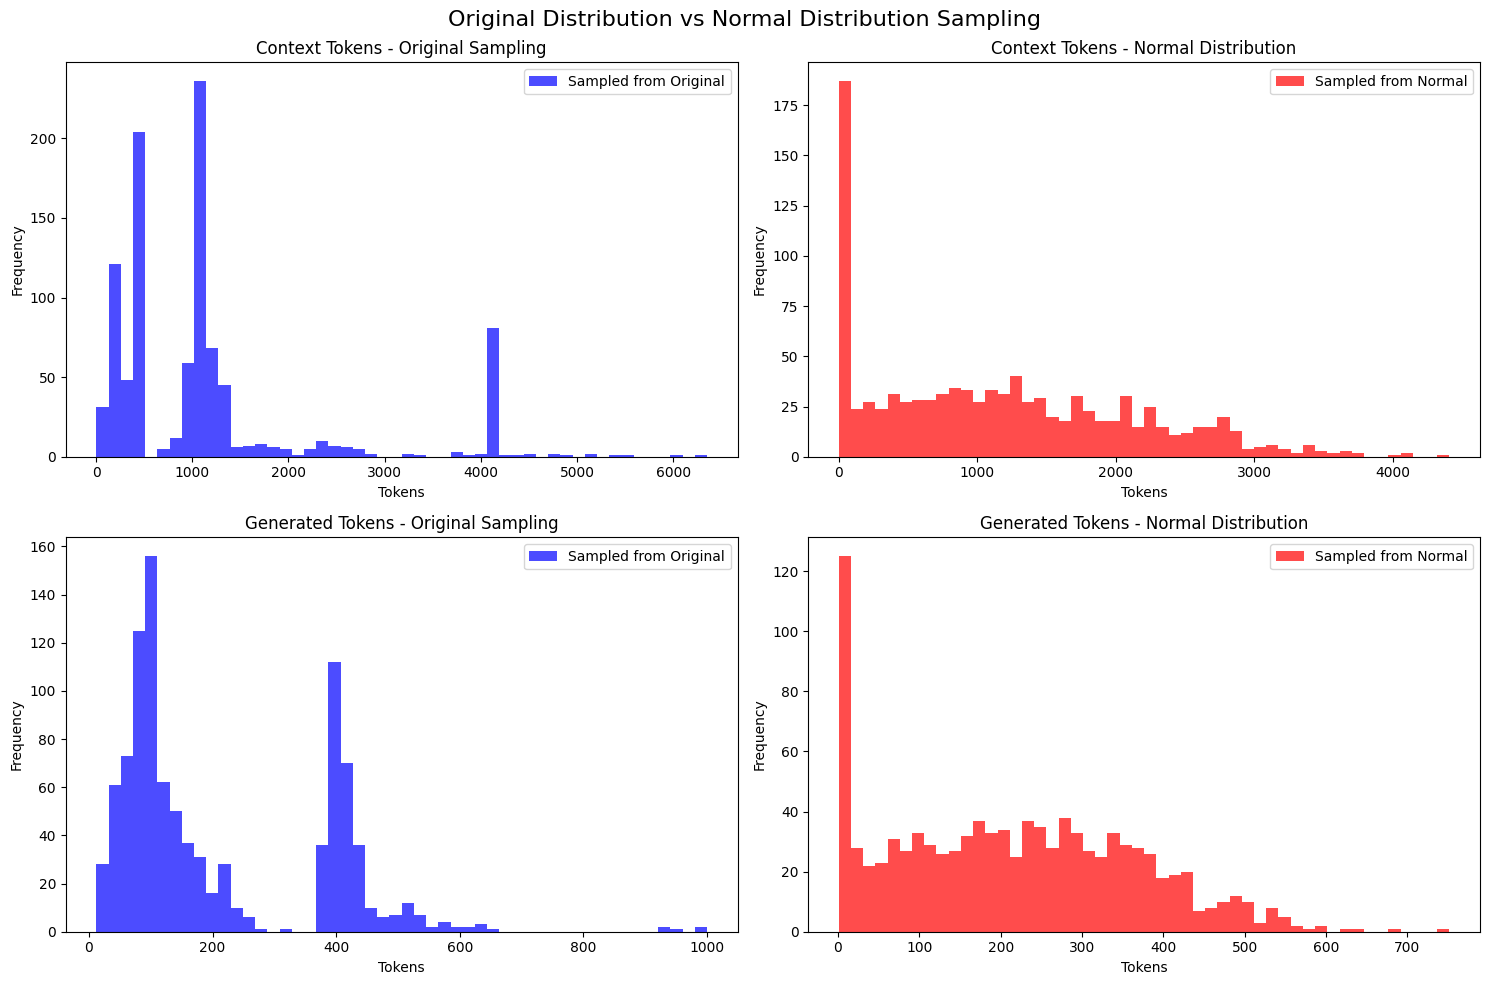


As you can see, the original distribution has different characteristics than a normal distribution!
The original has more realistic patterns, including:
- Heavy tails
- Multiple modes
- Realistic token count patterns

This is why sampling from the original distribution is much better!


In [17]:
# Test the Azure workload generator
import sys
import os
sys.path.append('/mnt/sdb1/aibrix-gangmuk/benchmarks/workload-generator')

# Test sampling from original distributions vs normal distribution
print("=== Comparison: Original vs Normal Distribution ===")

# Original Azure data
context_tokens_original = df_conv['ContextTokens'].values
generated_tokens_original = df_conv['GeneratedTokens'].values

print(f"Original Context Tokens - Mean: {np.mean(context_tokens_original):.2f}, Std: {np.std(context_tokens_original):.2f}")
print(f"Original Generated Tokens - Mean: {np.mean(generated_tokens_original):.2f}, Std: {np.std(generated_tokens_original):.2f}")

# Sample from original distribution
n_samples = 1000
sampled_context_original = np.random.choice(context_tokens_original, size=n_samples)
sampled_generated_original = np.random.choice(generated_tokens_original, size=n_samples)

# Sample from normal distribution (incorrect way)
sampled_context_normal = np.random.normal(np.mean(context_tokens_original), np.std(context_tokens_original), n_samples)
sampled_generated_normal = np.random.normal(np.mean(generated_tokens_original), np.std(generated_tokens_original), n_samples)

# Remove negative values from normal distribution
sampled_context_normal = np.maximum(1, sampled_context_normal)
sampled_generated_normal = np.maximum(1, sampled_generated_normal)

print(f"\nSampled from Original - Context Mean: {np.mean(sampled_context_original):.2f}, Generated Mean: {np.mean(sampled_generated_original):.2f}")
print(f"Sampled from Normal - Context Mean: {np.mean(sampled_context_normal):.2f}, Generated Mean: {np.mean(sampled_generated_normal):.2f}")

# Plot comparison
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Original Distribution vs Normal Distribution Sampling', fontsize=16)

# Context tokens comparison
axes[0,0].hist(sampled_context_original, bins=50, alpha=0.7, label='Sampled from Original', color='blue')
axes[0,0].set_title('Context Tokens - Original Sampling')
axes[0,0].set_xlabel('Tokens')
axes[0,0].set_ylabel('Frequency')
axes[0,0].legend()

axes[0,1].hist(sampled_context_normal, bins=50, alpha=0.7, label='Sampled from Normal', color='red')
axes[0,1].set_title('Context Tokens - Normal Distribution')
axes[0,1].set_xlabel('Tokens')
axes[0,1].set_ylabel('Frequency')
axes[0,1].legend()

# Generated tokens comparison
axes[1,0].hist(sampled_generated_original, bins=50, alpha=0.7, label='Sampled from Original', color='blue')
axes[1,0].set_title('Generated Tokens - Original Sampling')
axes[1,0].set_xlabel('Tokens')
axes[1,0].set_ylabel('Frequency')
axes[1,0].legend()

axes[1,1].hist(sampled_generated_normal, bins=50, alpha=0.7, label='Sampled from Normal', color='red')
axes[1,1].set_title('Generated Tokens - Normal Distribution')
axes[1,1].set_xlabel('Tokens')
axes[1,1].set_ylabel('Frequency')
axes[1,1].legend()

plt.tight_layout()
plt.show()

print("\nAs you can see, the original distribution has different characteristics than a normal distribution!")
print("The original has more realistic patterns, including:")
print("- Heavy tails")
print("- Multiple modes")
print("- Realistic token count patterns")
print("\nThis is why sampling from the original distribution is much better!")
